In [1]:
import os
import time

from SI.Practical_TM_SI import practical_TM_SI_randj
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Ananconda\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Ananconda\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Ananconda\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Ananconda\Lib\site-packages\tornado\platform\asyncio.py", line 205, in 

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [11]:
p, nt, ns, K = 100, 30, 50, 2
V = 3
sigma = 1.0
n_rep = 1000
#n_jobs = os.cpu_count()   # use every logical core
n_jobs = 12

In [12]:
print(n_jobs)

12


In [13]:
rng = np.random.default_rng(185)

X0 = rng.standard_normal((nt, p))
X_list = [rng.standard_normal((ns, p)) for _ in range(K)]

Sigma_0 = sigma ** 2 * np.eye(nt)
Sigma_K = [sigma ** 2 * np.eye(ns) for _ in range(K)]

In [14]:
p_values, branches, seconds = [], [], []  
kkt = {"observed fits": 0, "observed violations": 0, "SI fits": 0, "SI violations": 0}


def run(n_rep):
    n_empty = 0
    start = time.perf_counter()

    for i in range(1, n_rep + 1):
        y0 = sigma * rng.standard_normal(nt)
        y_list = [sigma * rng.standard_normal(ns) for _ in range(K)]

        t = time.perf_counter()
        result = practical_TM_SI_randj(
            X0, y0, X_list, y_list, Sigma_0, Sigma_K,
            V=V, rng=rng, n_jobs=n_jobs,
        )

        kkt["observed fits"] += result['kkt_observed']['fits']
        kkt["observed violations"] += result['kkt_observed']['violations']
        if result['results']:
            p_values.append(result['results'][0]['p_value'])
            branches.append(result['branch'])
            seconds.append(time.perf_counter() - t)
            kkt["SI fits"] += result['results'][0]['kkt_si']['fits']
            kkt["SI violations"] += result['results'][0]['kkt_si']['violations']
        else:
            n_empty += 1

        if i % 10 == 0:
            print(f"{i}/{n_rep}, "
                  f"p-values: {len(p_values)}, "
                  f"empty models: {n_empty}, "
                  f"time: {time.perf_counter() - start:.0f}s, "
                  f"KKT violations: observed {kkt['observed violations']}/{kkt['observed fits']}, "
                  f"SI {kkt['SI violations']}/{kkt['SI fits']}")

    return np.array(p_values), branches, n_empty

In [15]:
list_p_value, branches, n_empty = run(n_rep)

10/1000, p-values: 0, empty models: 10, time: 1s, KKT violations: observed 0/3200, SI 0/0
20/1000, p-values: 4, empty models: 16, time: 6s, KKT violations: observed 0/6400, SI 0/25960
30/1000, p-values: 10, empty models: 20, time: 15s, KKT violations: observed 0/9600, SI 1/67989
40/1000, p-values: 13, empty models: 27, time: 19s, KKT violations: observed 0/12800, SI 1/88094
50/1000, p-values: 15, empty models: 35, time: 23s, KKT violations: observed 0/16000, SI 1/102726
60/1000, p-values: 17, empty models: 43, time: 26s, KKT violations: observed 0/19200, SI 1/116471
70/1000, p-values: 21, empty models: 49, time: 32s, KKT violations: observed 0/22400, SI 3/145854
80/1000, p-values: 25, empty models: 55, time: 39s, KKT violations: observed 0/25600, SI 4/175070
90/1000, p-values: 27, empty models: 63, time: 42s, KKT violations: observed 0/28800, SI 5/186171
100/1000, p-values: 31, empty models: 69, time: 48s, KKT violations: observed 0/32000, SI 6/213287
110/1000, p-values: 37, empty mode

c:\Ananconda\Lib\site-packages\skglm\utils\anderson.py:43: RuntimeWarning: divide by zero encountered in divide
  C = inv_UTU_ones / np.sum(inv_UTU_ones)
c:\Ananconda\Lib\site-packages\skglm\utils\anderson.py:45: RuntimeWarning: invalid value encountered in matmul
  return self.arr_w_[:, 1:] @ C, self.arr_Xw_[:, 1:] @ C, True


750/1000, p-values: 231, empty models: 519, time: 393s, KKT violations: observed 0/240000, SI 33/1589032
760/1000, p-values: 234, empty models: 526, time: 398s, KKT violations: observed 0/243200, SI 33/1609351
770/1000, p-values: 235, empty models: 535, time: 400s, KKT violations: observed 0/246400, SI 33/1616098
780/1000, p-values: 237, empty models: 543, time: 405s, KKT violations: observed 0/249600, SI 35/1632779
790/1000, p-values: 238, empty models: 552, time: 407s, KKT violations: observed 0/252800, SI 35/1639081
800/1000, p-values: 240, empty models: 560, time: 411s, KKT violations: observed 0/256000, SI 35/1652106
810/1000, p-values: 242, empty models: 568, time: 415s, KKT violations: observed 0/259200, SI 36/1664626
820/1000, p-values: 244, empty models: 576, time: 419s, KKT violations: observed 0/262400, SI 36/1681011
830/1000, p-values: 247, empty models: 583, time: 424s, KKT violations: observed 0/265600, SI 36/1700625
840/1000, p-values: 251, empty models: 589, time: 432s,

In [16]:
alpha = 0.05
FPR = np.mean(list_p_value <= alpha)
print(f"FPR = {FPR}")

FPR = 0.06020066889632107


In [17]:
statistic, p_value = stats.kstest(list_p_value, 'uniform')
print(f'KS-Test statistic = {statistic}')
print(f'KS-Test p-value = {p_value}')

KS-Test statistic = 0.03264349559563812
KS-Test p-value = 0.8970446889149385


(array([20., 11., 19., 13., 13., 12., 15.,  8., 18., 19., 13., 14., 14.,
        21., 17., 15., 19., 11., 14., 13.]),
 array([0.00369295, 0.05339803, 0.1031031 , 0.15280818, 0.20251326,
        0.25221833, 0.30192341, 0.35162849, 0.40133356, 0.45103864,
        0.50074371, 0.55044879, 0.60015387, 0.64985894, 0.69956402,
        0.7492691 , 0.79897417, 0.84867925, 0.89838432, 0.9480894 ,
        0.99779448]),
 <BarContainer object of 20 artists>)

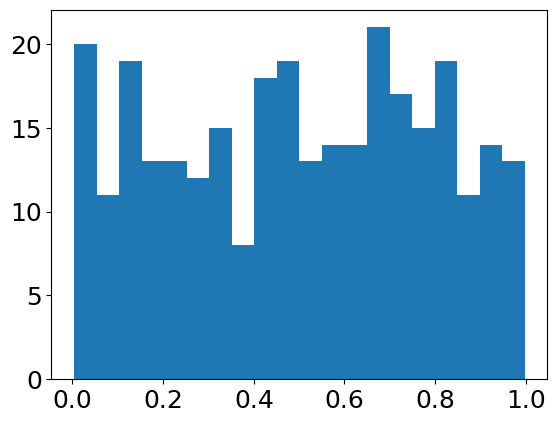

In [18]:
plt.hist(list_p_value, bins=20)

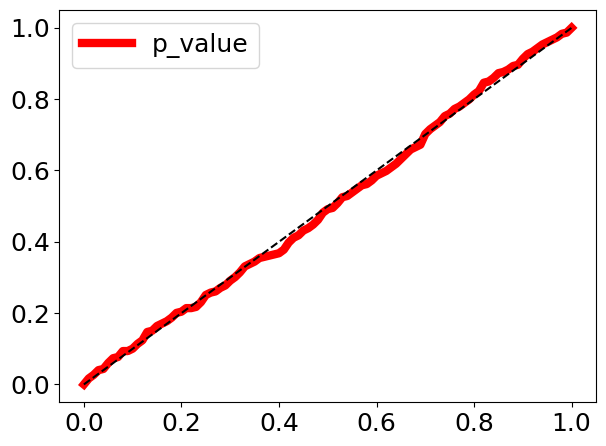

In [19]:
plt.rcParams.update({'font.size': 18})
grid = np.linspace(0, 1, 101)
ecdf = np.searchsorted(np.sort(list_p_value), grid, side='right') / len(list_p_value)
plt.plot(grid, ecdf, 'r-', linewidth=6, label='p_value')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.tight_layout()
plt.show()